<a href="https://colab.research.google.com/github/upgrade-projects/pysparks-projects/blob/main/Mini_Assignment_2_Rajeswari_Subramanian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

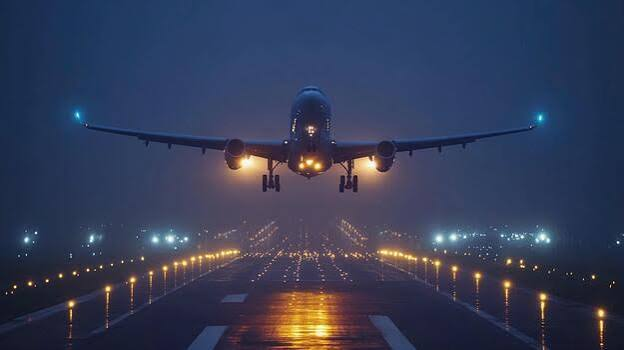

# **Domestic Flight Delay**


The data set ‘Domestic Flight Delay Records’ contains comprehensive data about domestic flights in the United States, such as flight dates, airtime, flight distance, scheduled departure/arrival times and departure and arrival delays.



Complete the following tasks using the provided data set:

Data Set [Link](https://drive.google.com/file/d/1WkheVqo_R0EkpeXv0lGQCrlBx4vShkiX/view?usp=drive_link)



With the given data set, solve the following tasks using PySpark.  

### **Mount Google Drive**

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Initialize SparkSession**

In [28]:
!pip install pyspark findspark
import findspark
findspark.init()
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, hour, avg, count

# Create a SparkSession
spark = SparkSession.builder.appName("FlightDelayAnalysis").getOrCreate()
print("SparkSession created successfully!")

SparkSession created successfully!


### **Load Dataset**

Load the dataset into a PySpark DataFrame.

In [29]:
# Path to your dataset in Google Drive
dataset_path = '/content/drive/MyDrive/Colab_Notebooks/Upgrad_Training/Cloud_Computing/data/Flight_Dataset.csv'

# Load the dataset
# Using 'header=True' to infer the first row as headers
# Using 'inferSchema=True' to automatically detect column types
df = spark.read.csv(dataset_path, header=True, inferSchema=True)

# Display the schema and first few rows to verify loading
print("DataFrame Schema:")
df.printSchema()

print("\nFirst 5 rows of the DataFrame:")
df.show(5)

DataFrame Schema:
root
 |-- FL_DATE: string (nullable = true)
 |-- DEP_DELAY: integer (nullable = true)
 |-- ARR_DELAY: integer (nullable = true)
 |-- AIR_TIME: integer (nullable = true)
 |-- DISTANCE: integer (nullable = true)
 |-- DEP_TIME: double (nullable = true)
 |-- ARR_TIME: double (nullable = true)


First 5 rows of the DataFrame:
+--------+---------+---------+--------+--------+---------+---------+
| FL_DATE|DEP_DELAY|ARR_DELAY|AIR_TIME|DISTANCE| DEP_TIME| ARR_TIME|
+--------+---------+---------+--------+--------+---------+---------+
|1/1/2006|        5|       19|     350|    2475| 9.083333|12.483334|
|1/2/2006|      167|      216|     343|    2475|11.783334|15.766666|
|1/3/2006|       -7|       -2|     344|    2475| 8.883333|12.133333|
|1/4/2006|       -5|      -13|     331|    2475| 8.916667|    11.95|
|1/5/2006|       -3|      -17|     321|    2475|     8.95|11.883333|
+--------+---------+---------+--------+--------+---------+---------+
only showing top 5 rows


### **Task 1**

Create a function that gives back how many flights arrived earlier than expected.


In [30]:
def count_early_arrivals(df):
    """
    Counts the number of flights that arrived earlier than expected.
    A flight arrived earlier than expected if 'ARR_DELAY' (Arrival Delay) is negative.

    Args:
        df (pyspark.sql.DataFrame): The input DataFrame containing flight data.

    Returns:
        int: The number of flights that arrived earlier than expected.
    """
    # Filter for flights where 'ARR_DELAY' is less than 0 (early arrival)
    early_arrivals_count = df.filter(col("ARR_DELAY") < 0).count()
    return early_arrivals_count

# Demonstrate the function
early_flights = count_early_arrivals(df)
print(f"Number of flights that arrived earlier than expected: {early_flights}")

Number of flights that arrived earlier than expected: 534655


#### **Result**
There are **534,655** flights that arrived earlier than expected (i.e., `ARR_DELAY` < 0).

### **Task 2**

Create a function that determines the typical departure time for flights over 2000 miles.

In [31]:
def typical_departure_time_long_flights(df):
    """
    Determines the typical departure time for flights over 2000 miles.
    This is calculated as the average departure hour for such flights.

    Args:
        df (pyspark.sql.DataFrame): The input DataFrame containing flight data.

    Returns:
        float: The typical departure hour for flights over 2000 miles.
    """
    # Filter for flights over 2000 miles and calculate the average departure hour
    # 'DEP_TIME' is a double representing hours (e.g., 9.083333 for ~9:05 AM).
    # Casting to 'int' extracts the hour part.
    typical_dep_time = df.filter(col("DISTANCE") > 2000) \
                         .withColumn("DepHour", col("DEP_TIME").cast("int")) \
                         .select(avg("DepHour")) \
                         .collect()[0][0]
    return typical_dep_time

# Demonstrate the function
typical_dep_hour = typical_departure_time_long_flights(df)
print(f"Typical departure hour for flights over 2000 miles: {typical_dep_hour:.2f}")

Typical departure hour for flights over 2000 miles: 13.46


#### **Result**
The typical departure hour for flights over 2000 miles is approximately **13.46** (around 1:28 PM).

### **Task 3**

Create a function that gives back the proportion of flights that have arrival delays longer than 60 minutes.

In [32]:
def proportion_long_arrival_delays(df):
    """
    Calculates the proportion of flights that have arrival delays longer than 60 minutes.

    Args:
        df (pyspark.sql.DataFrame): The input DataFrame containing flight data.

    Returns:
        float: The proportion of flights with arrival delays > 60 minutes.
    """
    total_flights = df.count()
    if total_flights == 0:
        return 0.0

    # Count flights with arrival delays greater than 60 minutes
    long_delay_flights = df.filter(col("ARR_DELAY") > 60).count()

    proportion = long_delay_flights / total_flights
    return proportion

# Demonstrate the function
proportion = proportion_long_arrival_delays(df)
print(f"Proportion of flights with arrival delays longer than 60 minutes: {proportion:.4f}")

Proportion of flights with arrival delays longer than 60 minutes: 0.0531


#### **Result**
The proportion of flights with arrival delays longer than 60 minutes is **0.0531** (or 5.31%).

### **Task 4**

Create a function that gives the average airtime for flights that left earlier than 9:00 am.

In [33]:
def average_airtime_early_departures(df):
    """
    Calculates the average airtime for flights that left earlier than 9:00 am.

    Args:
        df (pyspark.sql.DataFrame): The input DataFrame containing flight data.

    Returns:
        float: The average airtime for early morning departures.
    """
    # Filter for flights departing before 9.0 (9:00 am) and calculate the average AIR_TIME
    # 'DEP_TIME' is a double representing hours (e.g., 9.083333).
    average_airtime = df.filter(col("DEP_TIME") < 9.0) \
                        .select(avg("AIR_TIME")) \
                        .collect()[0][0]
    return average_airtime

# Demonstrate the function
avg_airtime = average_airtime_early_departures(df)
print(f"Average airtime for flights that left earlier than 9:00 am: {avg_airtime:.2f} minutes")

Average airtime for flights that left earlier than 9:00 am: 111.36 minutes


#### **Result**
The average airtime for flights that left earlier than 9:00 am is **111.36 minutes**.

### **Task 5**

Create a function that determines the maximum arrival delay for flights that did not experience a delay upon departure.

In [34]:
def max_arrival_delay_no_departure_delay(df):
    """
    Determines the maximum arrival delay for flights that did not experience a delay upon departure.
    A flight did not experience a delay upon departure if 'DEP_DELAY' is less than or equal to 0.

    Args:
        df (pyspark.sql.DataFrame): The input DataFrame containing flight data.

    Returns:
        int or None: The maximum arrival delay for flights with no departure delay, or None if no such flights exist.
    """
    # Filter for flights with no departure delay (DEP_DELAY <= 0) and find the maximum 'ARR_DELAY'
    max_delay = df.filter(col("DEP_DELAY") <= 0) \
                    .select(col("ARR_DELAY")) \
                    .agg({"ARR_DELAY": "max"}) \
                    .collect()[0][0]
    return max_delay

# Demonstrate the function
max_arr_delay = max_arrival_delay_no_departure_delay(df)
if max_arr_delay is not None:
    print(f"Maximum arrival delay for flights with no departure delay: {max_arr_delay} minutes")
else:
    print("No flights found that departed without a delay.")

Maximum arrival delay for flights with no departure delay: 701 minutes


#### **Result**
The maximum arrival delay for flights that did not experience a delay upon departure is **701 minutes**.

 Stop the SparkSession to free up resources.

In [35]:
# Stop the SparkSession
spark.stop()
print("SparkSession stopped.")

SparkSession stopped.
